# Working with Unlabeled Data – Cluster Analysis
Find the best number of clusters with __k_means__ and __agglomerative clustering__

## Overview

1. Load the data file
    - check the shape and plot the content  
1. Observe the pair plot and comment the shapes in view of clustering 
    1. if necessary, transform the data
1. Use the elbow method to find the optimal number of clusters, to do this test `KMeans` with varying number of clusters, from 2 to 10: for each value of `k` 
    - fit the data
    - compute the __inertia__ and the __silhouette score__  
    - store them for plot
1. Plot inertia and silhouette score versus `k`
1. Choose the optimal number of clusters looking at the plots
1. Cluster the data using the optimal number, plot the cluster assignment 
    - in the plot choose the features that seem to be most promising
1. For comparison, repeat the same operation with the `AgglomerativeClustering` and `DBSCAN`
        

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from mpl_toolkits import mplot3d
from sklearn.model_selection import ParameterGrid
import warnings
warnings.filterwarnings("ignore")

random_state = 42 # This variable will be used in all the procedure calls allowing a random_state parameter
               # in this way the running can be perfectly reproduced
               # just change this value for a different experiment

## 1. Load the data file
Check the shape and plot the content 

In [31]:
# Step 1: Load the data file
url = "C:/Users/jacop/OneDrive/Documenti/BBS_Machine_Learning_public/data/wholesale.csv"
delimeter = ","
X0 = pd.read_csv(url, delimiter=delimeter)
X0.shape
   




(440, 8)

In [32]:
X0.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


## 2. Observe the data distributions

In [33]:
X0.boxplot(figsize=(15,10))


<Axes: >

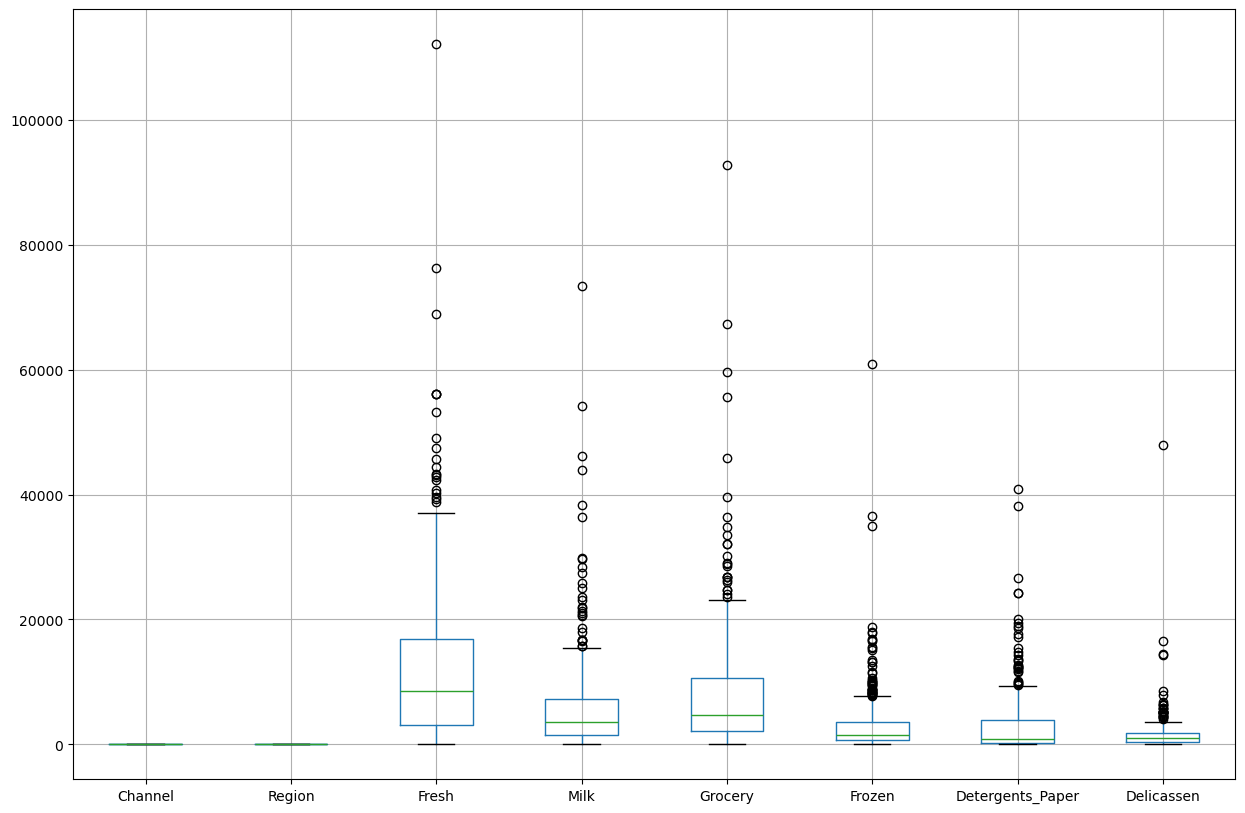

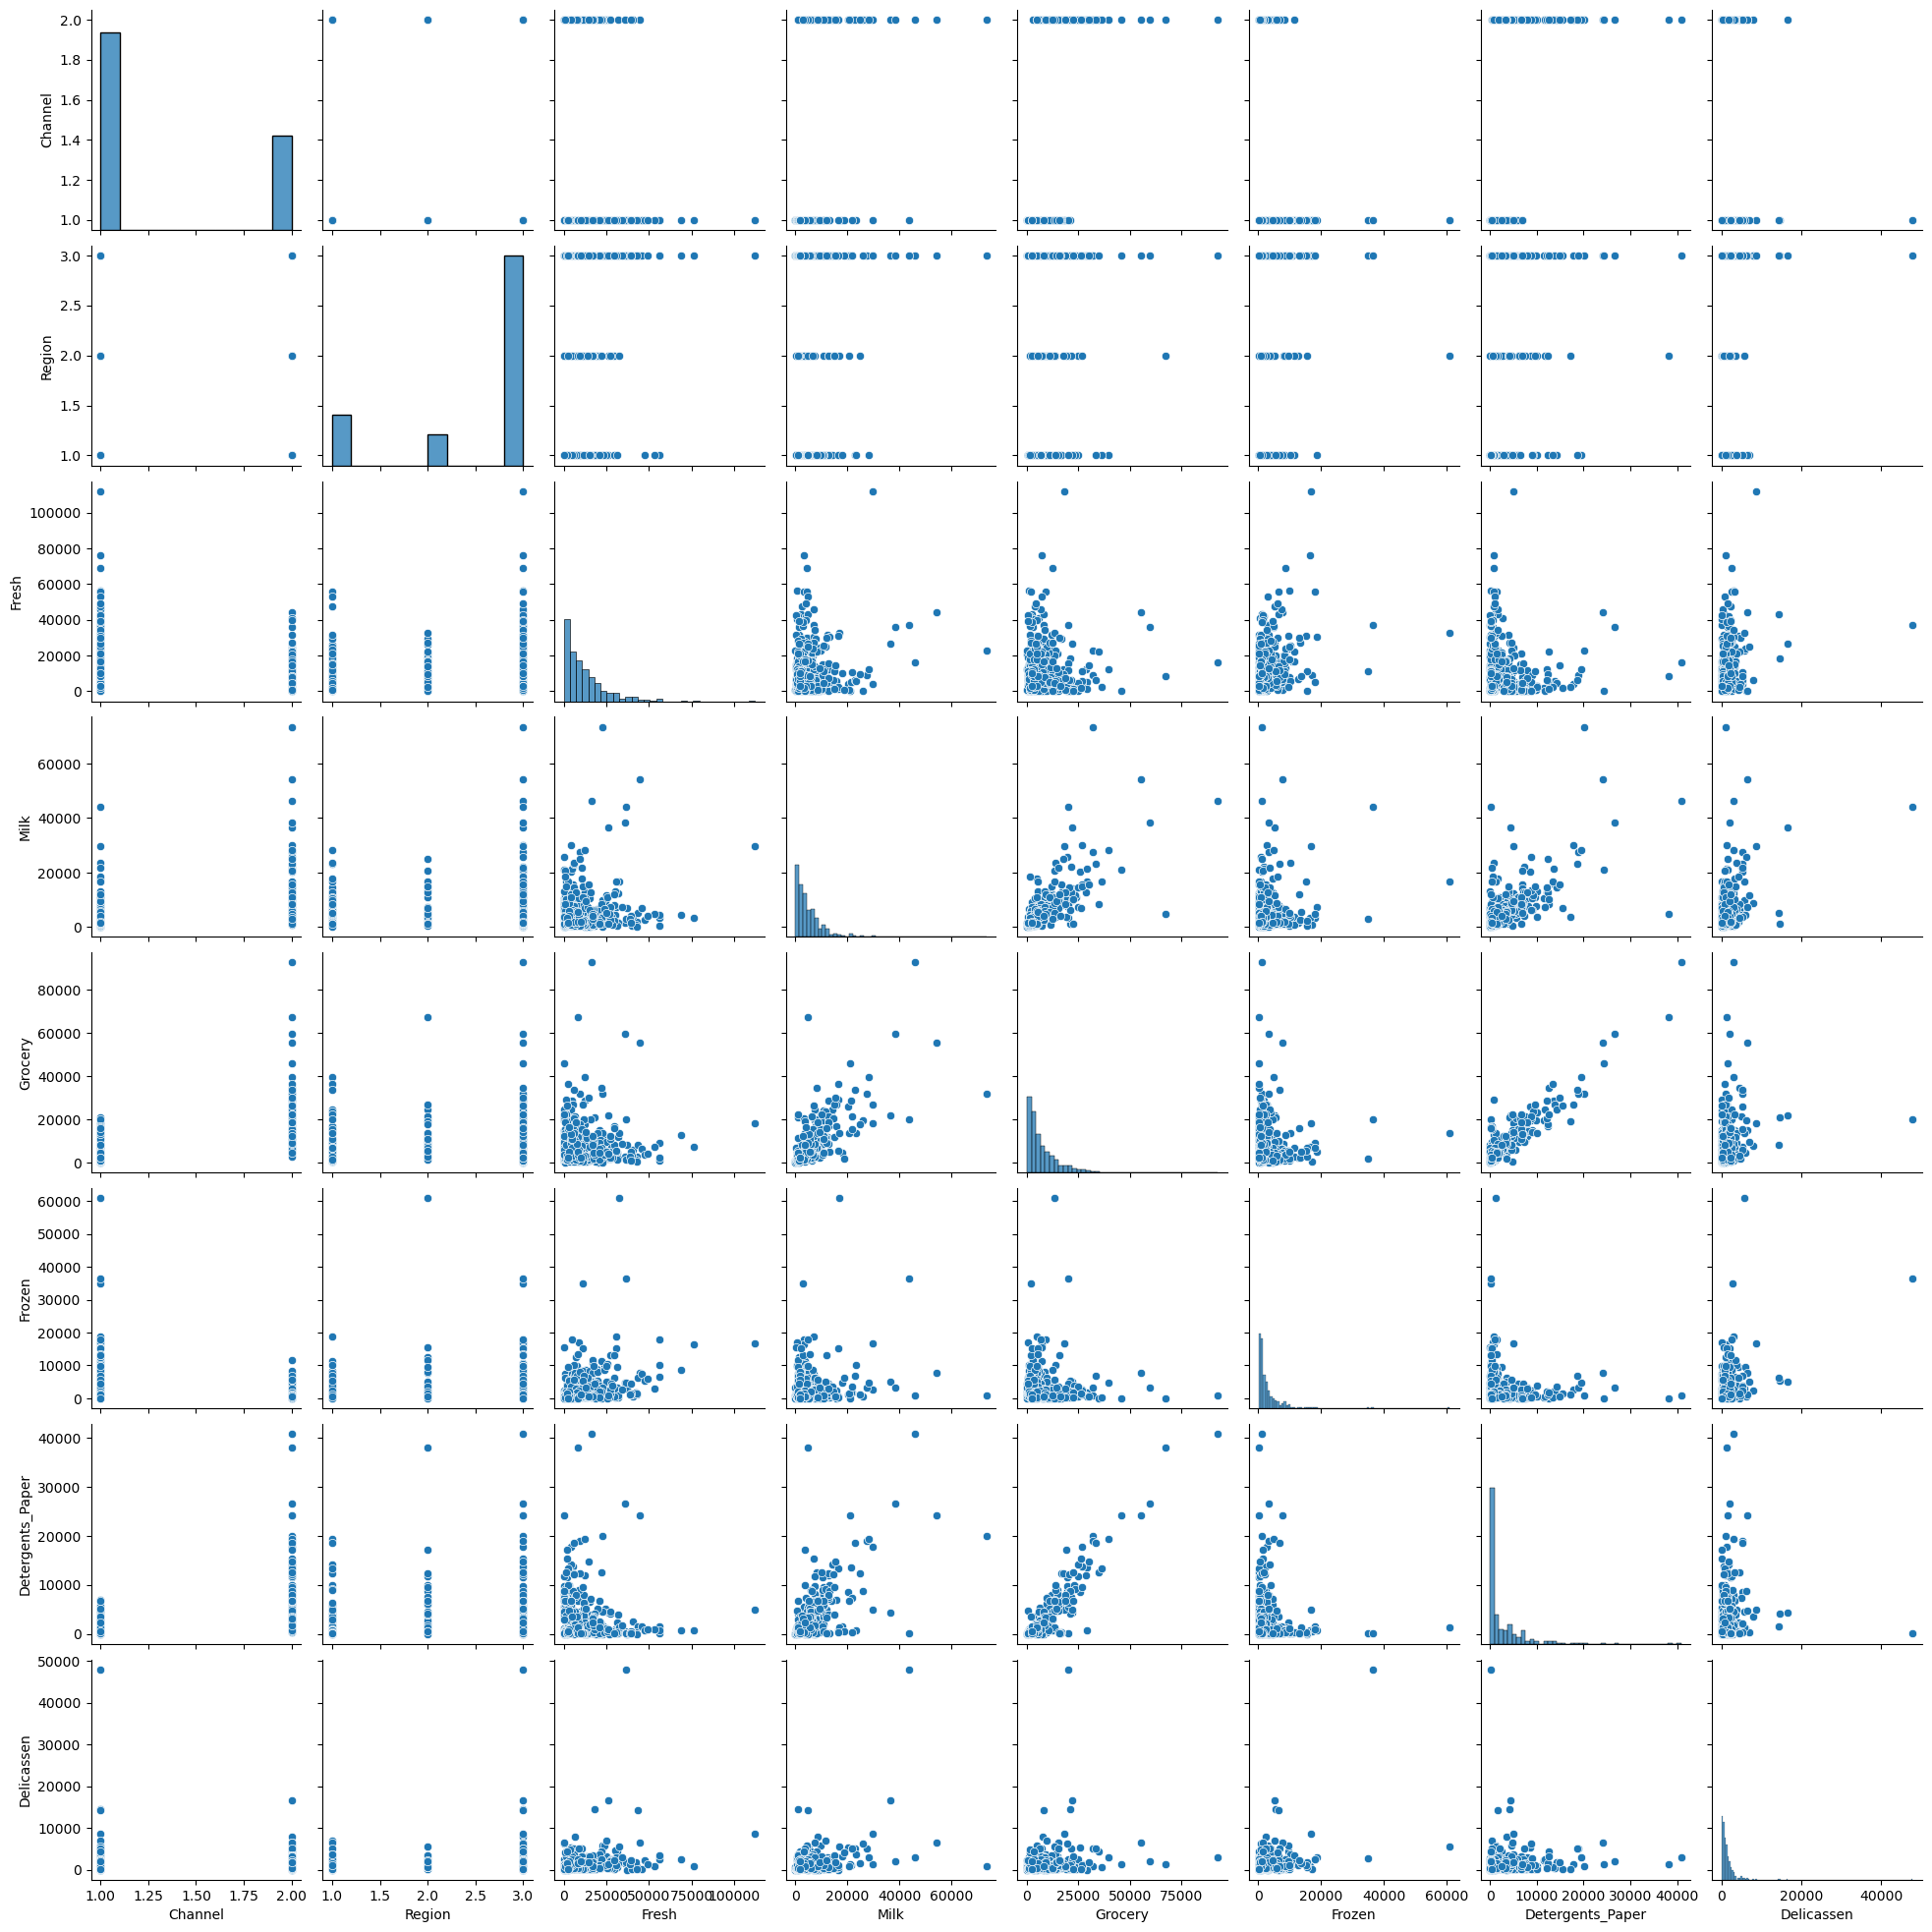

In [34]:
sns.pairplot(X0)
plt.show()

We observe that the distributions of values are definitely *skewed*: in the columns from `Fresh` to `Delicassen` the values are highly concentrated on the right, but there are always outliers, frequently in a very large range.

Clustering is more effective in absence of outliers and with all the variables distributed in similar ranges, for this reason, we will execute two transformations:
1. transform all the variables from the column `Fresh` to the column `Delicassen` with [PowerTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PowerTransformer.html)
1. remap all the variables in the range `0:1`

In [35]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer()
X_pt = pd.DataFrame(pt.fit_transform(X0.iloc[:,2:]),columns=X0.columns[2:])
X_trasf = pd.concat([X0.iloc[:,:2],X_pt],axis=1)
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
X = pd.DataFrame(mms.fit_transform(X_trasf), columns = X_trasf.columns)
X.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,1.0,1.0,0.501828,0.667606,0.625238,0.208640,0.649941,0.412016
1,1.0,1.0,0.414266,0.670028,0.655690,0.458800,0.674852,0.445663
2,1.0,1.0,0.400077,0.653586,0.627297,0.499856,0.682752,0.654292
3,0.0,1.0,0.509368,0.369264,0.553550,0.636716,0.461095,0.446485
4,1.0,1.0,0.604755,0.580657,0.618985,0.566470,0.601884,0.590255


Show the result of the transformation

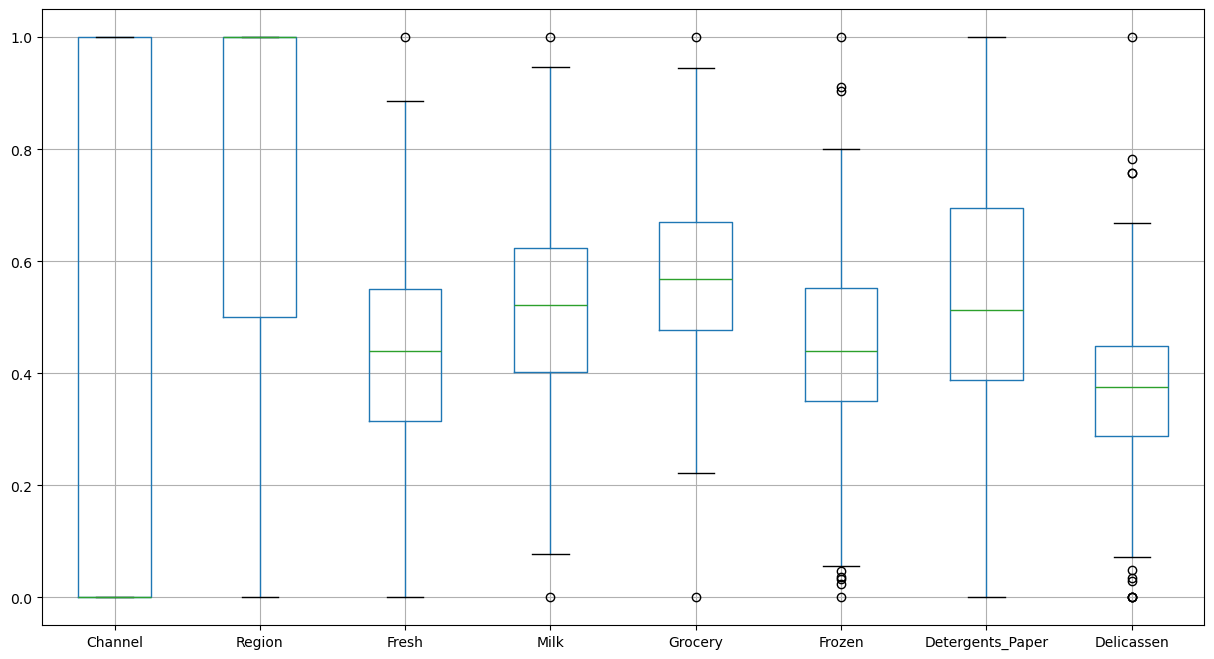

In [36]:
X.boxplot(figsize=(15,8));
plt.show()

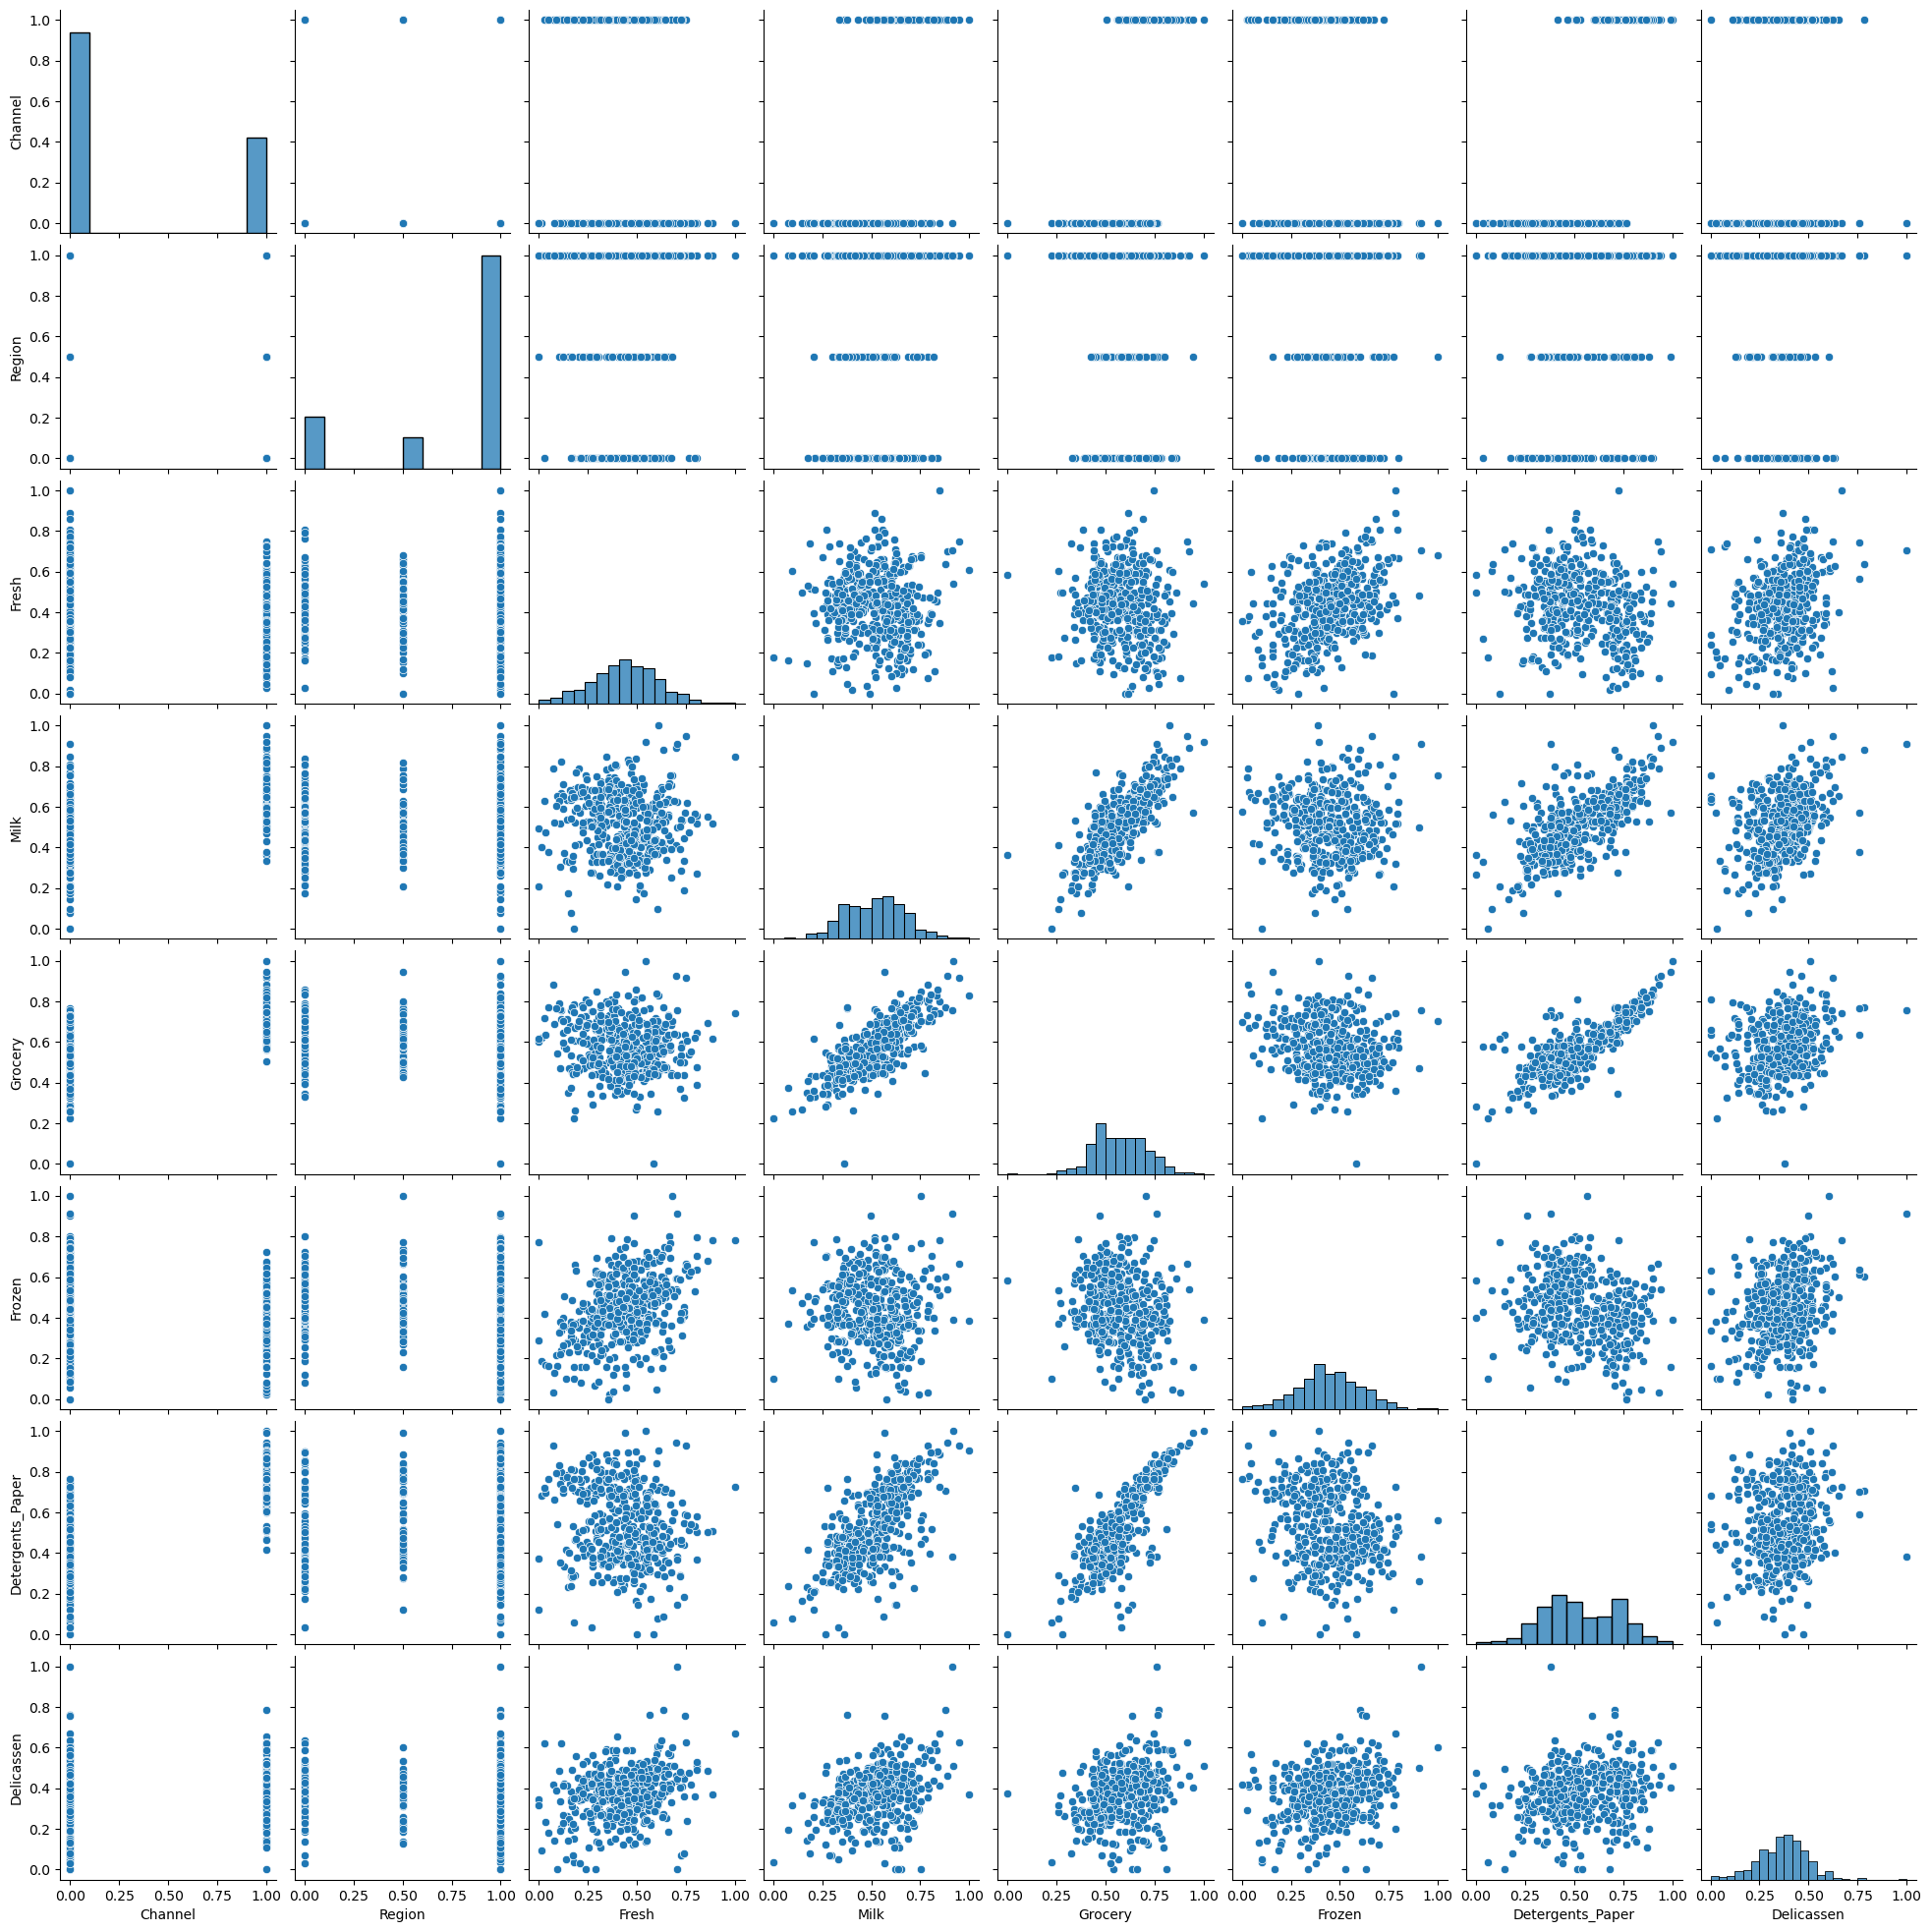

In [37]:
sns.pairplot(X)
plt.show()  

Now the effect of outliers is reduced, and we compute the clustering

## 3. Use the elbow method to find the optimal number of clusters
Test `KMeans` with varying number of clusters, from 2 to 10

Prepare the results list that will contain pairs of `inertia` and `silhouette_score` for each value of `k`, then, __for each value__ of `k` 
- initialize an estimator for `KMeans`
- fit the data and predict the cluster assignment for each individual with `fit` and `predict`
- the __inertia__ is provided in the attribute `inertia_` of the fitted model
- compute the __silhouette score__  using the function `silhouette_score` from `sklearn.metrics` using as arguments the data and the fitted labels, we will fill the variable `silhouette_scores`
- store the two values above in the list created at the beginning

In [38]:
k_range = list(range(2,11)) # set the range of k values to test 
parameters_km = [{'n_clusters': k_range}]
pg = ParameterGrid(parameters_km)
inertias_km = []
silhouette_scores_km = []
for pv in pg:
    km = KMeans(**(pv), random_state=random_state)
    y_km = km.fit_predict(X)
    inertias_km.append(km.inertia_)
    silhouette_scores_km.append(silhouette_score(X,y_km))

## 4. Plot __inertia__ and __silhouette score__ versus `k`

In [39]:
def two_plots(x, y1, y2, xlabel, y1label, y2label):
    fig, ax1 = plt.subplots()

    color = 'tab:red'
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel(y1label, color=color)
    ax1.plot(x, y1, color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

    color = 'tab:blue'
    ax2.set_ylabel(y2label, color=color)  # we already handled the x-label with ax1
    ax2.plot(x, y2, color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.set_ylim(0,1) # the axis for silhouette is [0,1]

    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    plt.show()

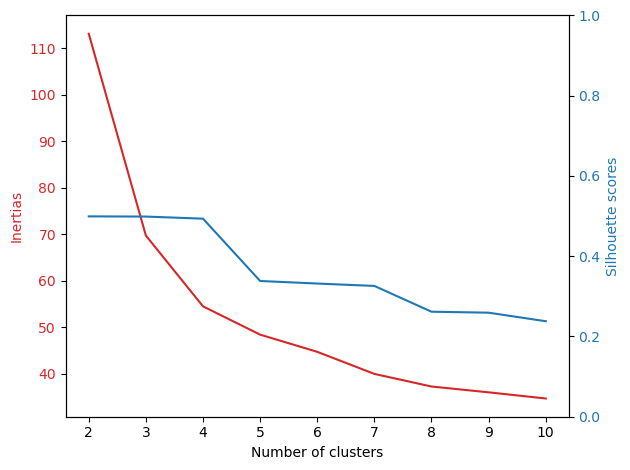

In [40]:
two_plots(x=k_range, y1=inertias_km, y2=silhouette_scores_km
          , xlabel='Number of clusters', y1label='Inertias', y2label='Silhouette scores'
         )

## 5. Cluster with the optimal number
The two *elbow* points of inertia would suggest as cluster number 3 or 4, slightly more pronounced in 3. Silhouette has a maximum on 4, but the increase with respect to 3 is very small.

We will choose k=4

In [41]:
k=4
km = KMeans(n_clusters=k, 
            random_state=random_state)
y_km = km.fit_predict(X)
print("Number of clusters = {}\t- Distortion = {:6.2f}\t- Silhouette score = {:4.2f}"\
    .format(k,inertias_km[k_range.index(k)],silhouette_scores_km[k_range.index(k)]))

Number of clusters = 4	- Distortion =  54.49	- Silhouette score = 0.49


Show the distribution of samples in the clusters with a pie chart

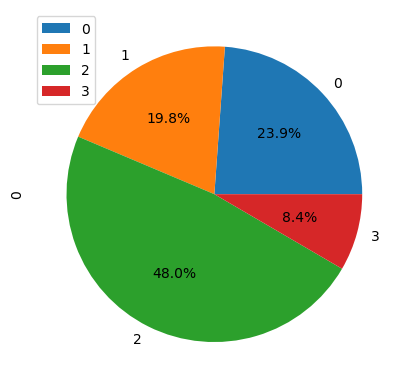

In [42]:
clust_sizes_km = np.unique(y_km,return_counts=True)
pd.DataFrame(clust_sizes_km[1]).plot.pie(y=0, autopct='%1.1f%%', );
plt.show()

### Comments
The __silhouette score__ ranges from `-1` (worst) to `1` (best); as a rule of thumb, a value greater than `0.5` should be considered acceptable.

## Agglomerative clustering
We will try a grid of parameter configurations, with the number of clusters in the range `2:10` and the four linkage methods available in the *sklearn* implementation of *AgglomerativeClustering*. 

In [43]:
from sklearn.cluster import AgglomerativeClustering

In [44]:
parameters = [
    {
        'n_clusters': k_range,
        'linkage': ['ward','complete','average','single']
    }
]
pg = ParameterGrid(parameters)
result_ac = []
for params in pg:
    ac = AgglomerativeClustering(**params)
    y_ac = ac.fit_predict(X)
    silhouette = silhouette_score(X,y_ac)
    result_ac.append([params['linkage'],params['n_clusters'],silhouette])   
df_result_ac = pd.DataFrame(data=result_ac,columns=['linkage','n_clusters','silhouette_score'])
df_result_ac = df_result_ac.sort_values(by='silhouette_score',ascending=False)
df_result_ac

,linkage,n_clusters,silhouette_score
0,ward,2,0.499350
9,complete,2,0.499350
27,single,2,0.499350
18,average,2,0.499350
1,ward,3,0.498333
2,ward,4,0.493085
20,average,4,0.479507
11,complete,4,0.479507
21,average,5,0.475050
22,average,6,0.443867


The top five results have a very similar silhouette score, we will choose the setting with 4 clusters, as for k-means, and the linkage giving the best result with 4 clusters, that is `ward`. This is the result record with `index 2` (the record index is the unnamed column at the very left of the dataframe output

In [45]:
print("Selected configuration for Agglomerative Clustering (3rd best result):")
print(df_result_ac.iloc[[2]])

Selected configuration for Agglomerative Clustering (3rd best result):
   linkage  n_clusters  silhouette_score
27  single           2           0.49935


In [46]:
ac = AgglomerativeClustering(**pg[2])
y_ac = ac.fit_predict(X)
clust_sizes_ac = np.unique(y_ac,return_counts=True)
cluster_distribution_ac = pd.DataFrame({
    'Cluster': clust_sizes_ac[0],
    'Size': clust_sizes_ac[1]
})

Show the distribution of data in the clusters

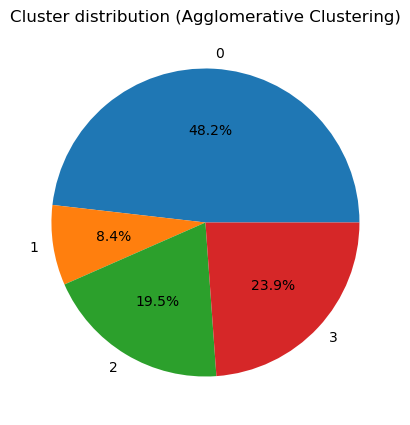

In [47]:
cluster_distribution_ac.set_index('Cluster').plot.pie(
    y="Size",
    autopct='%1.1f%%',
    legend=False,
    figsize=(5,5),
    title="Cluster distribution (Agglomerative Clustering)"
)
plt.ylabel('')
plt.show()

Pairplot for KMeans clustering


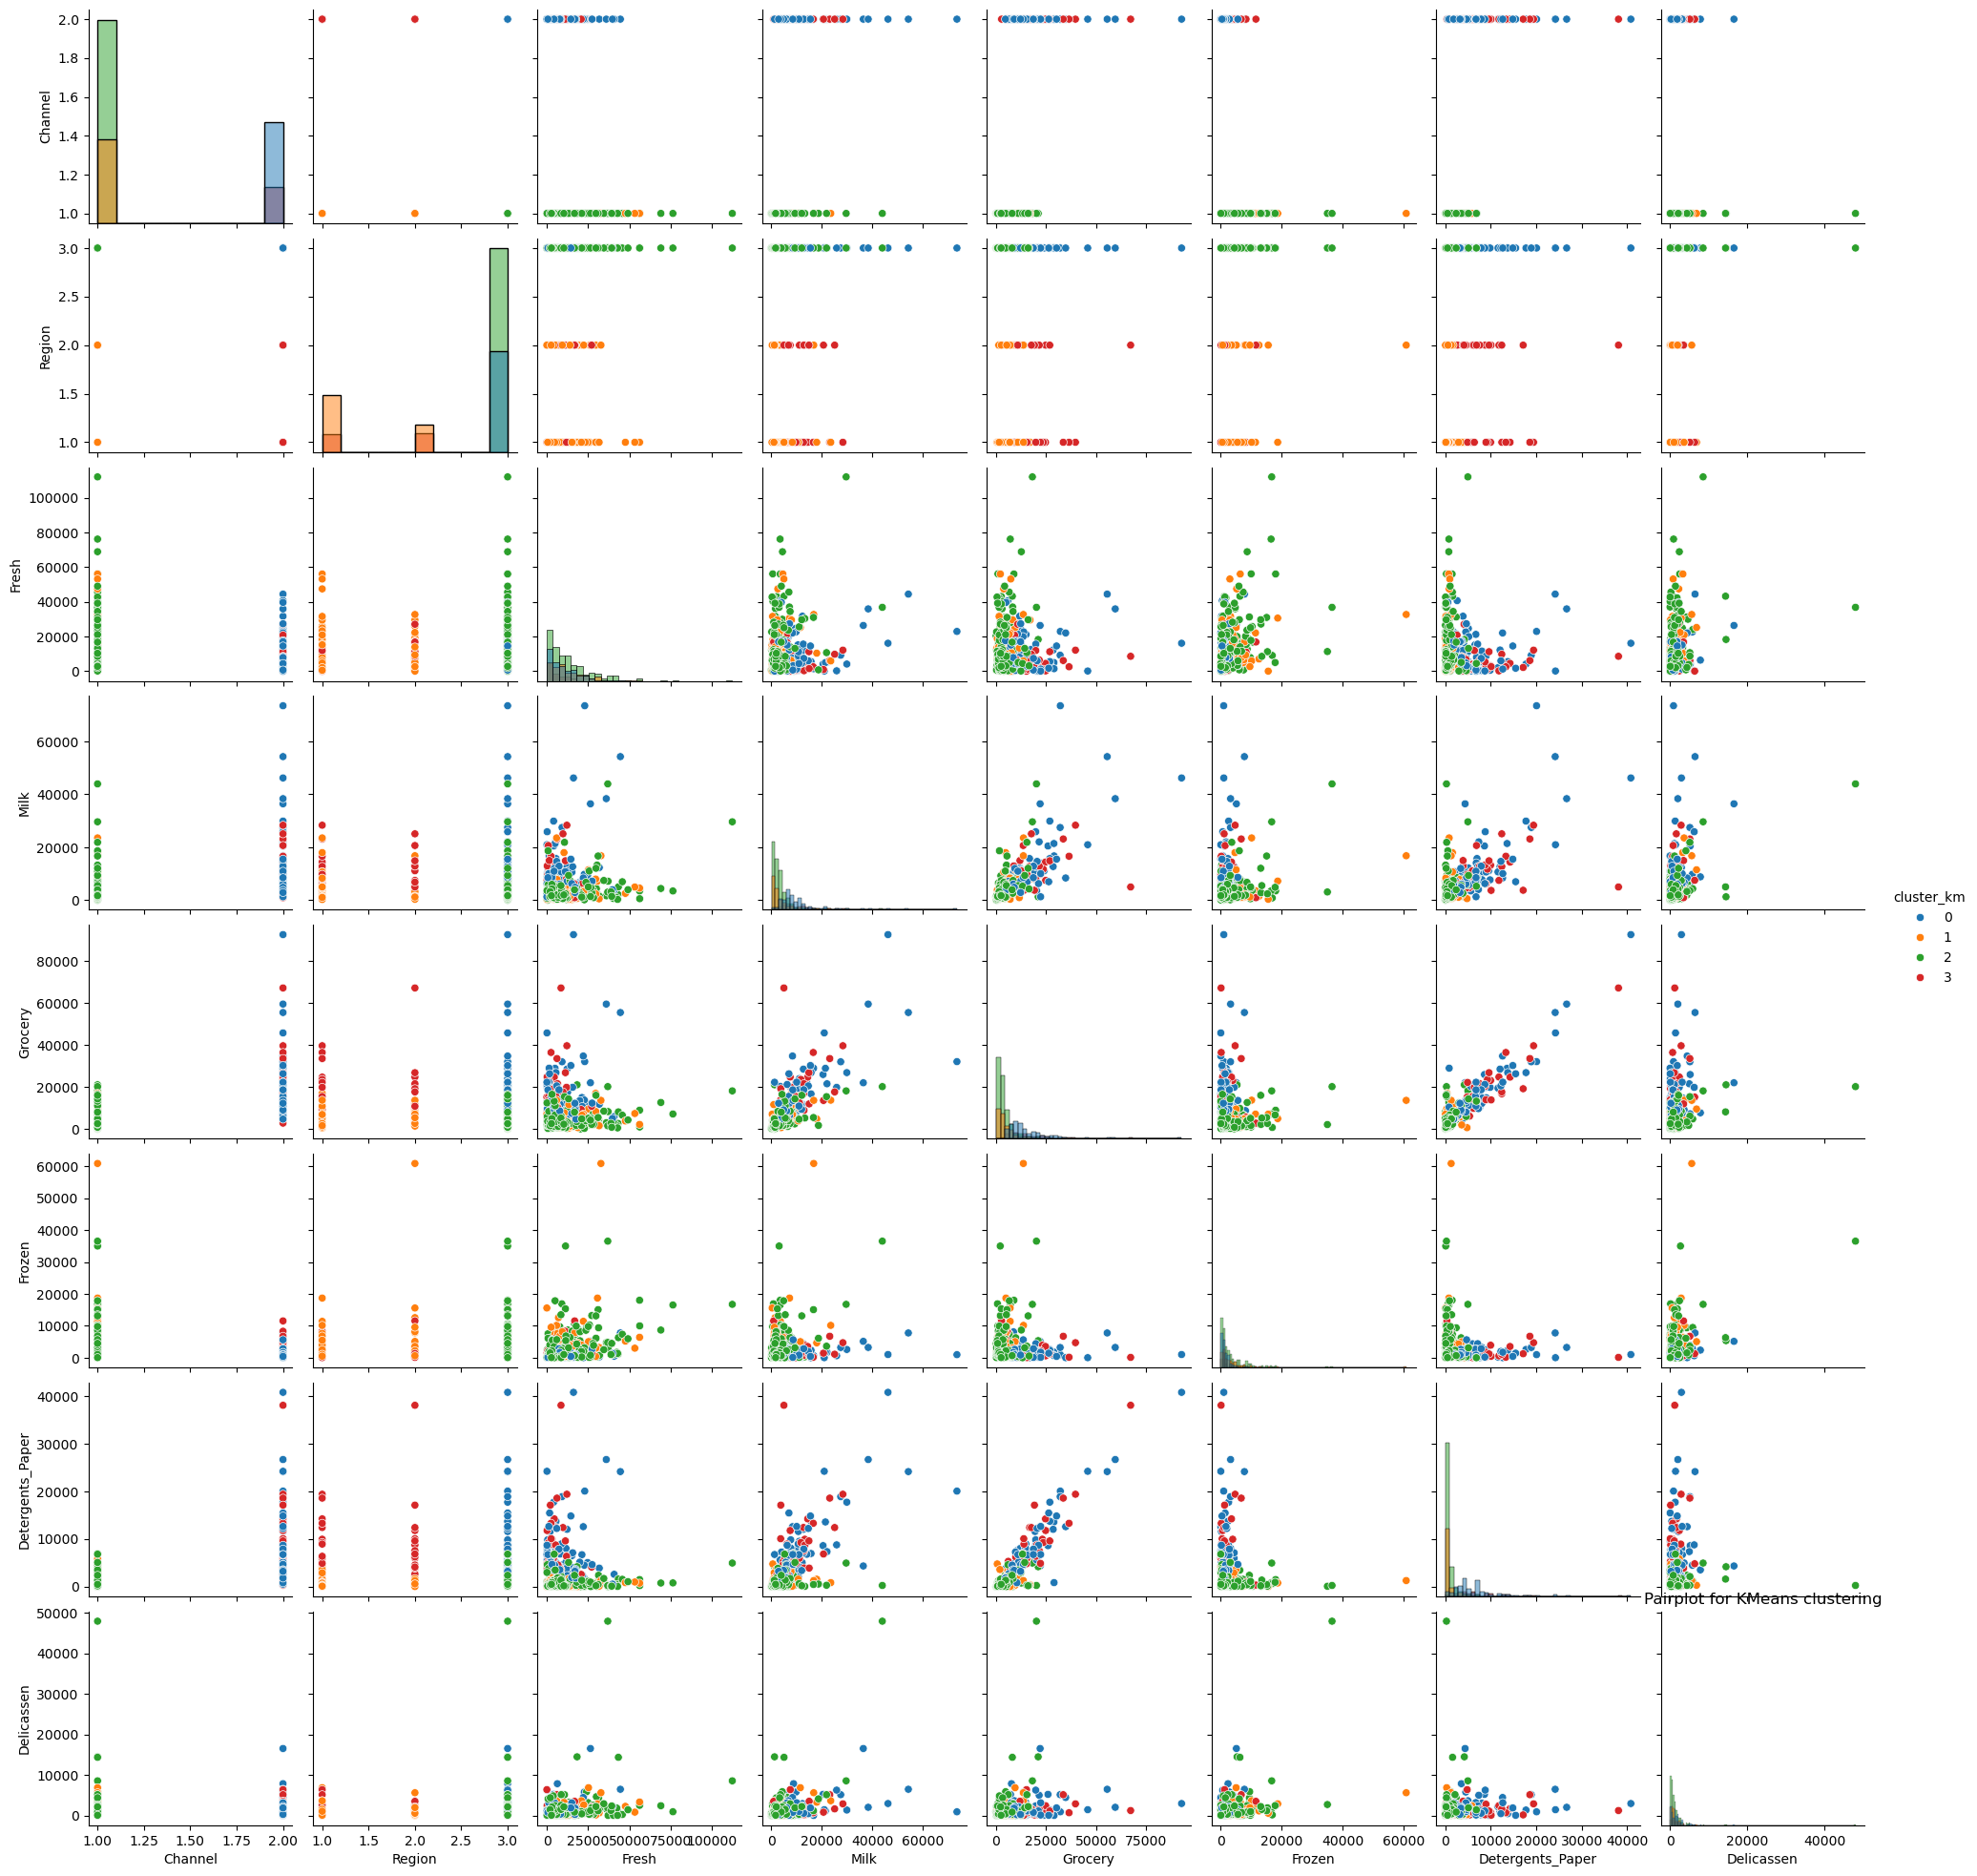

In [48]:
X0['cluster_km'] = y_km
print('Pairplot for KMeans clustering')
sns.pairplot(data=X0, hue='cluster_km', diag_kind='hist', palette='tab10')
plt.title('Pairplot for KMeans clustering')
plt.show()

Pairplot for Agglomerative clustering


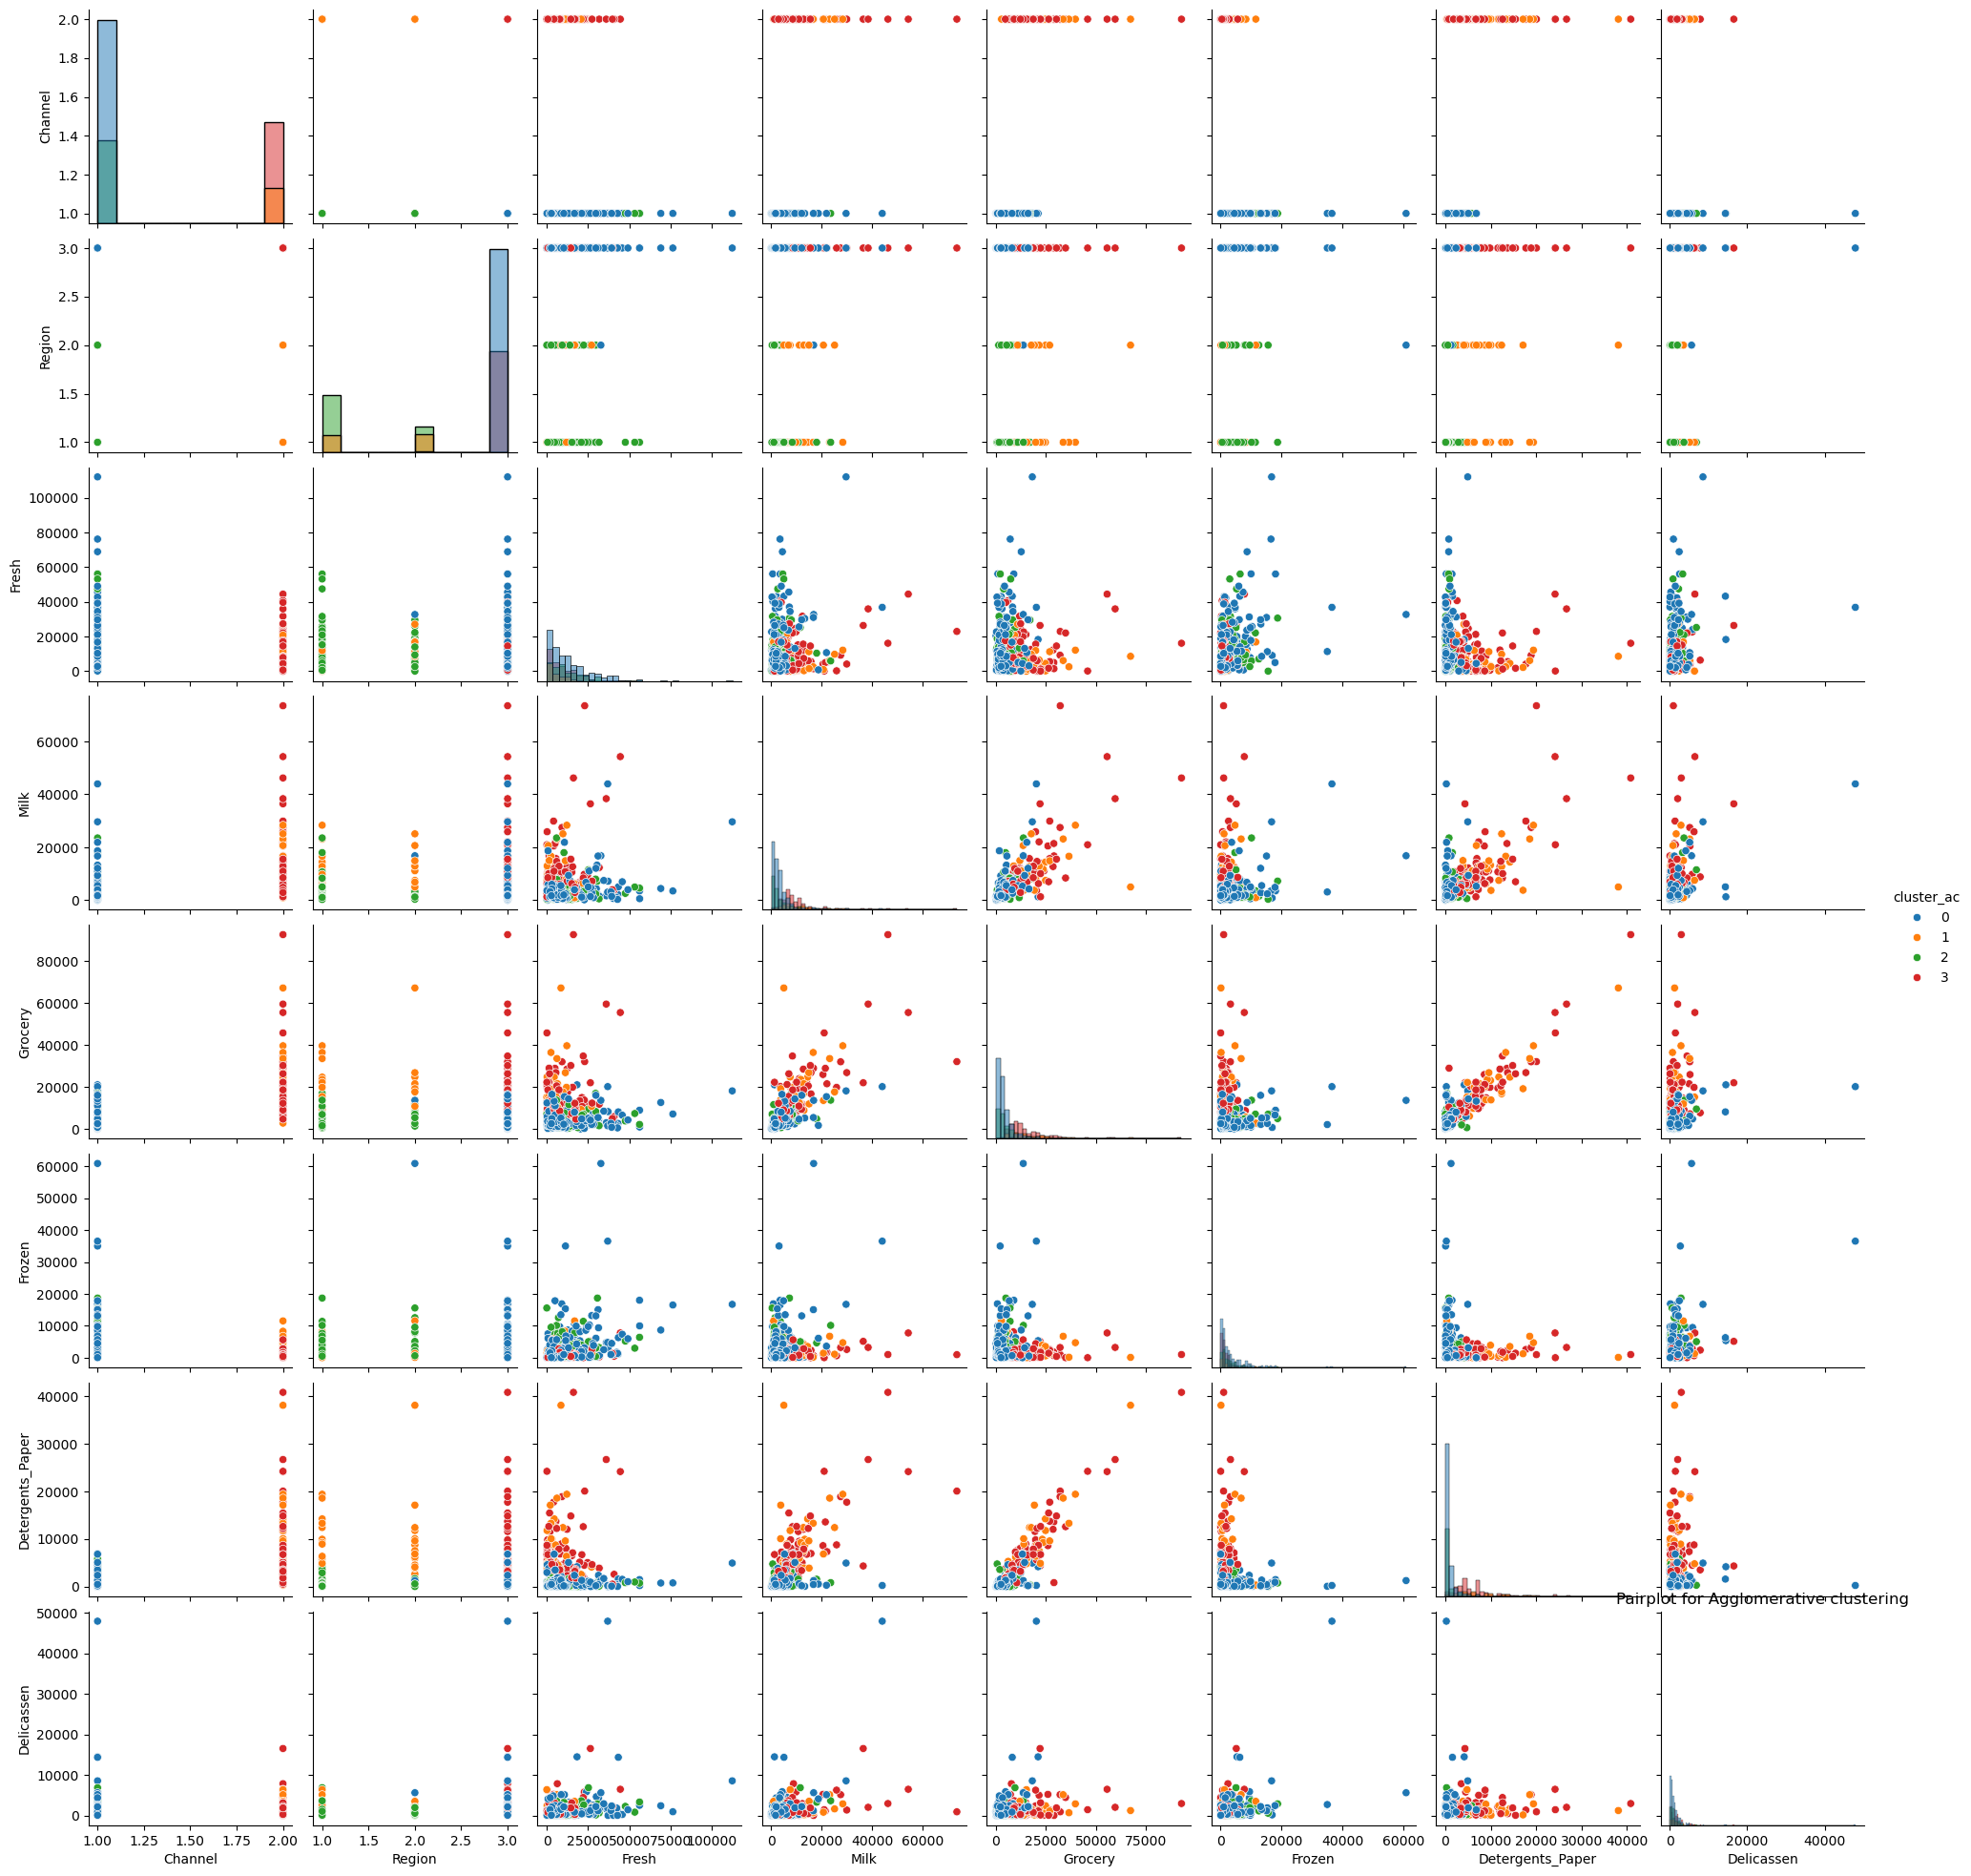

In [49]:
X0['cluster_ac'] = y_ac
print('Pairplot for Agglomerative clustering')
sns.pairplot(data=X0.drop('cluster_km', axis=1),hue='cluster_ac',diag_kind='hist',palette='tab10')
plt.title('Pairplot for Agglomerative clustering')
plt.show()

### Comments


The solution with the Agglomerative Clustering in this case provides a result very similar to that of kmeans.

It is interesting to compare more deeply the results of the two clustering models. 

The function `pair_confusion_matrix` computes the number of pairs of objects that are in the same clusters or in different clusters in two different clustering schemes. 

The result is given in a 2x2 matrix, the smaller the numbers out of the main diagona, the better the match.

For easier readability, we divide all the elements of the matrix by the sum of all the elements of the matrix, in this way, the matrix elements are normalized to 1.

In [50]:
from sklearn.metrics import pair_confusion_matrix
pcm = pair_confusion_matrix(y_km,y_ac)
normalized_pcm = pcm/pcm.sum()
print('Normalized Pair Confusion Matrix:')
print(normalized_pcm)

Normalized Pair Confusion Matrix:
[[0.66625595 0.00218472]
 [0.00089045 0.33066888]]


A short indicator of the match percentage can be optained as a sum of the elements of the main diagonal.

In [51]:
matching_percentage = (normalized_pcm.diagonal().sum()*100)
print("The percentage of match between the two clustering schemes is {:6.2f}%".format(matching_percentage))

The percentage of match between the two clustering schemes is  99.69%


## DBSCAN

In [54]:
from sklearn.cluster import DBSCAN
db = DBSCAN()
y_db = db.fit_predict(X)

In [58]:
print("Default parameters - Eps={} - Min_Samples={}".format(db.eps,db.min_samples))

Default parameters - Eps=0.5 - Min_Samples=5


In [59]:
X0['cluster_db'] = y_db

Show the distribution of data in the clusters

Pairplot for DBSCAN Clustering:


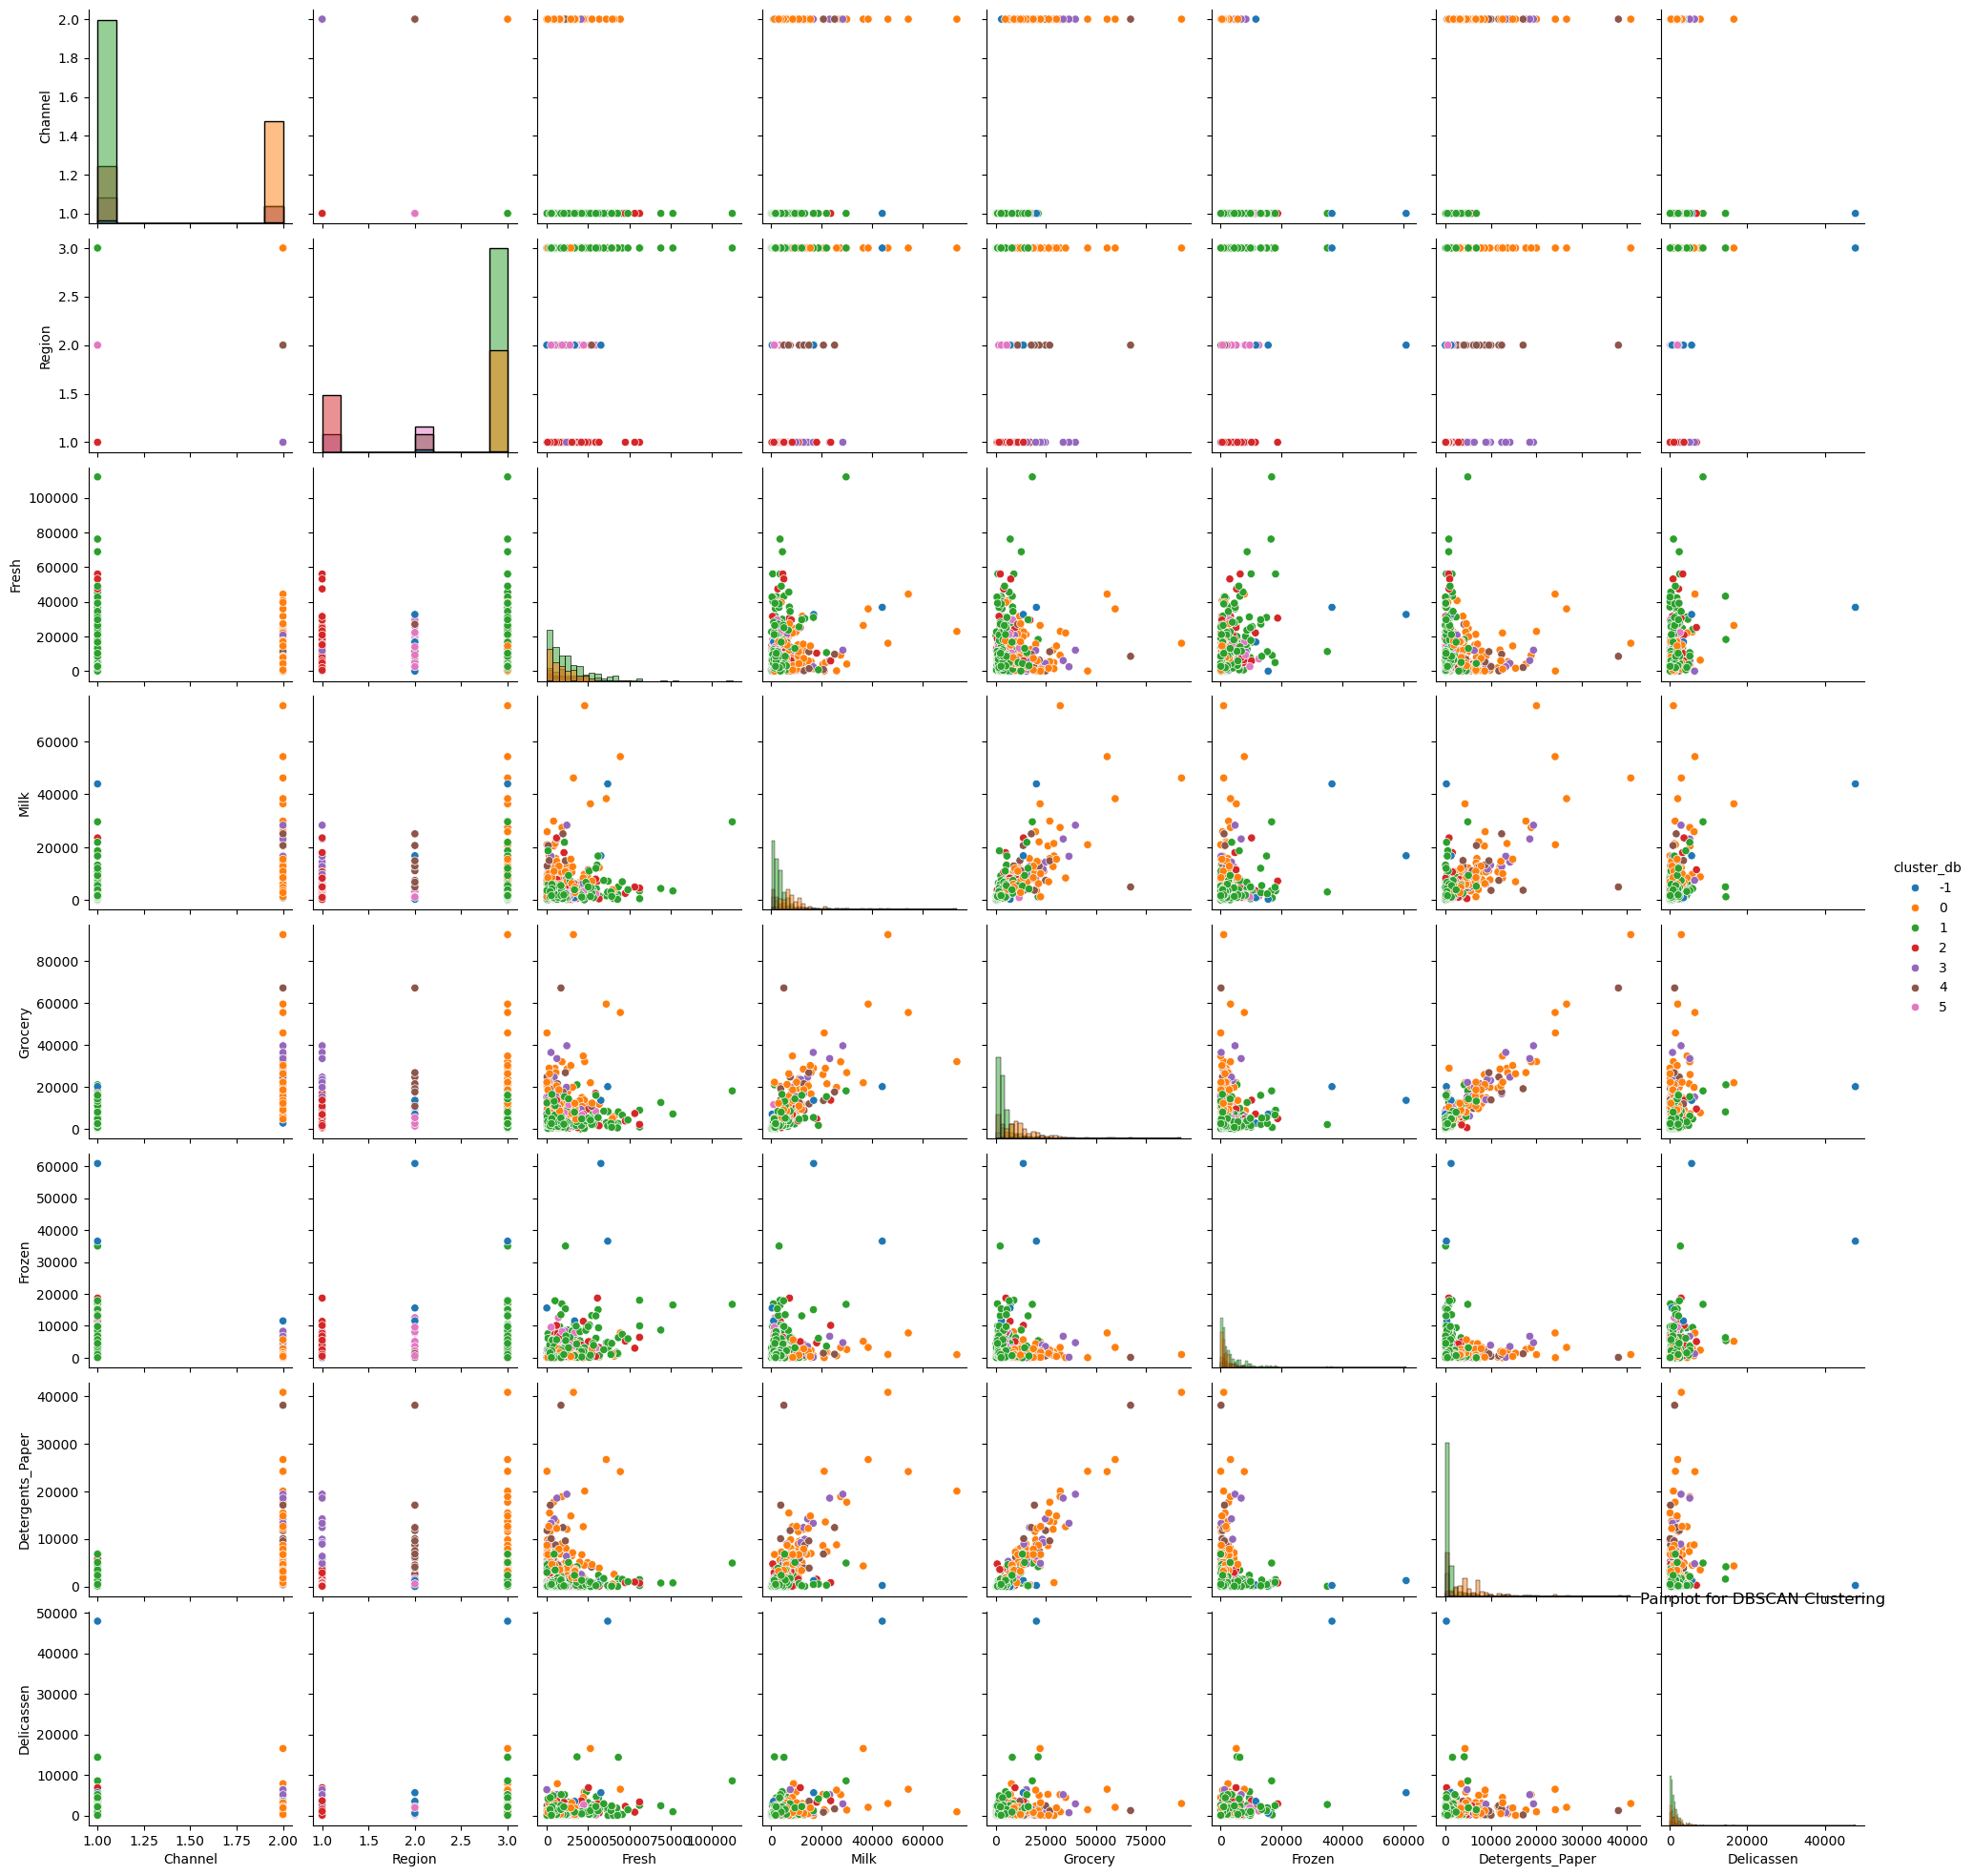

In [60]:
print("Pairplot for DBSCAN Clustering:")
sns.pairplot(data=X0.drop(['cluster_km', 'cluster_ac'], axis=1), hue='cluster_db', diag_kind='hist', palette='tab10')
plt.title("Pairplot for DBSCAN Clustering")
plt.show()


Pie Chart for DBSCAN Cluster Distribution:


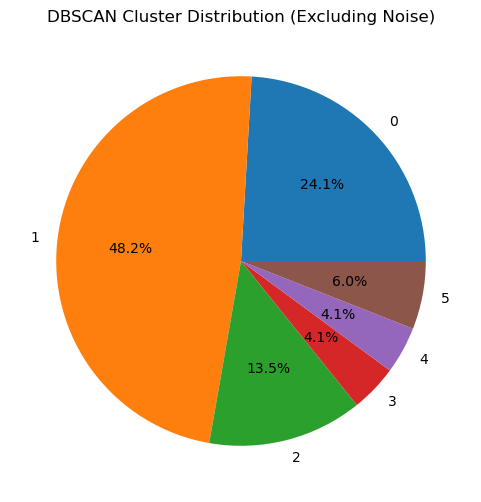

In [61]:
# Exclude noise points (-1) and calculate cluster sizes
clust_sizes_db = np.unique(y_db[y_db != -1], return_counts=True)


# Create a DataFrame for cluster sizes and plot a pie chart
print("Pie Chart for DBSCAN Cluster Distribution:")
cluster_distribution_db = pd.DataFrame({
   'Cluster': clust_sizes_db[0],
   'Size': clust_sizes_db[1]
})


cluster_distribution_db.set_index('Cluster').plot.pie(
   y='Size',
   autopct='%1.1f%%',
   legend=False,
   figsize=(6, 6),
   title="DBSCAN Cluster Distribution (Excluding Noise)"
)
plt.ylabel('')  # Remove the default ylabel for better appearance
plt.show()


### 5. Find the best parameters using `ParameterGrid`

prepare the dictionary of the parameter ranges and produce the list of parameter settings to test with the function `ParameterGrid`

In [62]:
param_grid = {'eps': list(np.arange(0.001, 1, 0.005)), 'min_samples': list(range(2,10,1))}
pg = ParameterGrid(param_grid)

Arrange DBSCAN results in a dataframe, for easier presentation and filtering

`dbscan_out = pd.DataFrame(columns =  ['eps','min_samples','n_clusters','silhouette', 'unclust%'])`

- for each parameter setting

In [65]:
# Initialize a DataFrame to store DBSCAN results
dbscan_out = pd.DataFrame(columns=['eps', 'min_samples', 'n_clusters', 'silhouette', 'unclust%'])


# Iterate over all parameter combinations
for pv in pg:
   db = DBSCAN(**pv)  # Initialize DBSCAN with current parameters
   y_db = db.fit_predict(X)  # Fit DBSCAN and predict cluster assignments
  
   # Identify clusters and exclude noise (-1)
   cluster_labels_all = np.unique(y_db)  # All cluster labels, including noise
   cluster_labels = cluster_labels_all[cluster_labels_all != -1]  # Exclude noise
   n_clusters = len(cluster_labels)  # Count the number of clusters (excluding noise)
  
   # Evaluate only if the number of clusters is valid (1 < n_clusters < len(y_db))
   if 1 < n_clusters and n_clusters < len(y_db):
       # Filter out unclustered points for silhouette score calculation
       X_cl = X.loc[y_db != -1, :]  # Only clustered points
       y_db_cl = y_db[y_db != -1]   # Cluster labels excluding noise
      
       # Compute silhouette score
       silhouette = silhouette_score(X_cl, y_db_cl)
      
       # Compute the percentage of unclustered points (noise)
       uncl_p = (1 - y_db_cl.shape[0] / y_db.shape[0]) * 100
      
       # Store the results in the DataFrame
       dbscan_out.loc[len(dbscan_out)] = [pv['eps'], pv['min_samples'], n_clusters, silhouette, uncl_p]


In [66]:
# Define thresholds for filtering results
sil_thr = 0.5  # Minimum silhouette score threshold
unc_thr = 10   # Maximum percentage of unclustered points
n_clu_max_thr = 5  # Maximum number of clusters to consider


# Filter results based on thresholds and sort
filtered_results = dbscan_out[
   (dbscan_out['silhouette'] >= sil_thr) &
   (dbscan_out['unclust%'] <= unc_thr) &
   (dbscan_out['n_clusters'] <= n_clu_max_thr)
].sort_values(['silhouette', 'unclust%'], ascending=[False, True])
print("Filtered Results (Silhouette >= {}, Unclustered <= {}%, Clusters <= {}):".format(sil_thr, unc_thr, n_clu_max_thr))
print(filtered_results)

Filtered Results (Silhouette >= 0.5, Unclustered <= 10%, Clusters <= 5):
       eps  min_samples  n_clusters  silhouette  unclust%
652  0.506          2.0         4.0    0.529010  0.909091
653  0.506          3.0         4.0    0.529010  0.909091
654  0.506          4.0         4.0    0.529010  0.909091
655  0.506          5.0         4.0    0.529010  0.909091
656  0.506          6.0         4.0    0.529010  0.909091
..     ...          ...         ...         ...       ...
743  0.561          5.0         2.0    0.500188  0.227273
744  0.561          6.0         2.0    0.500188  0.227273
745  0.561          7.0         2.0    0.500188  0.227273
746  0.561          8.0         2.0    0.500188  0.227273
747  0.561          9.0         2.0    0.500188  0.227273

[96 rows x 5 columns]


In [67]:
# Filter results where the number of clusters equals 4
filtered_results_4_clusters = dbscan_out[
   (dbscan_out['n_clusters'] == 4)
].sort_values(['silhouette', 'unclust%'], ascending=[False, True])


print("Results for 4 Clusters:")
print(filtered_results_4_clusters)

Results for 4 Clusters:
       eps  min_samples  n_clusters  silhouette   unclust%
0    0.051          2.0         4.0    0.809127  98.181818
55   0.131          5.0         4.0    0.577401  75.681818
114  0.166          8.0         4.0    0.564877  59.090909
123  0.171          9.0         4.0    0.556483  57.500000
122  0.171          8.0         4.0    0.554163  55.454545
131  0.176          9.0         4.0    0.552283  54.772727
130  0.176          8.0         4.0    0.551633  53.181818
139  0.181          9.0         4.0    0.549653  53.863636
138  0.181          8.0         4.0    0.549119  51.590909
120  0.171          6.0         4.0    0.546914  49.545455
111  0.166          5.0         4.0    0.545816  50.681818
128  0.176          6.0         4.0    0.544325  46.363636
147  0.186          9.0         4.0    0.538980  50.000000
119  0.171          5.0         4.0    0.537250  46.590909
652  0.506          2.0         4.0    0.529010   0.909091
653  0.506          3.0         

### 6. Observe  
- Observe visually the most promising combination of parameters reproducing the same number of clusters of the previous experiments 
- fit and predict the cluster labels and show a pairplot

In [70]:
# Define the best parameters for DBSCAN
best = {'eps': 0.506, 'min_samples': 2}


# Initialize and fit DBSCAN using the best parameters
db = DBSCAN(**best)
y_db = db.fit_predict(X)





Pairplot for DBSCAN Clustering with Best Parameters:


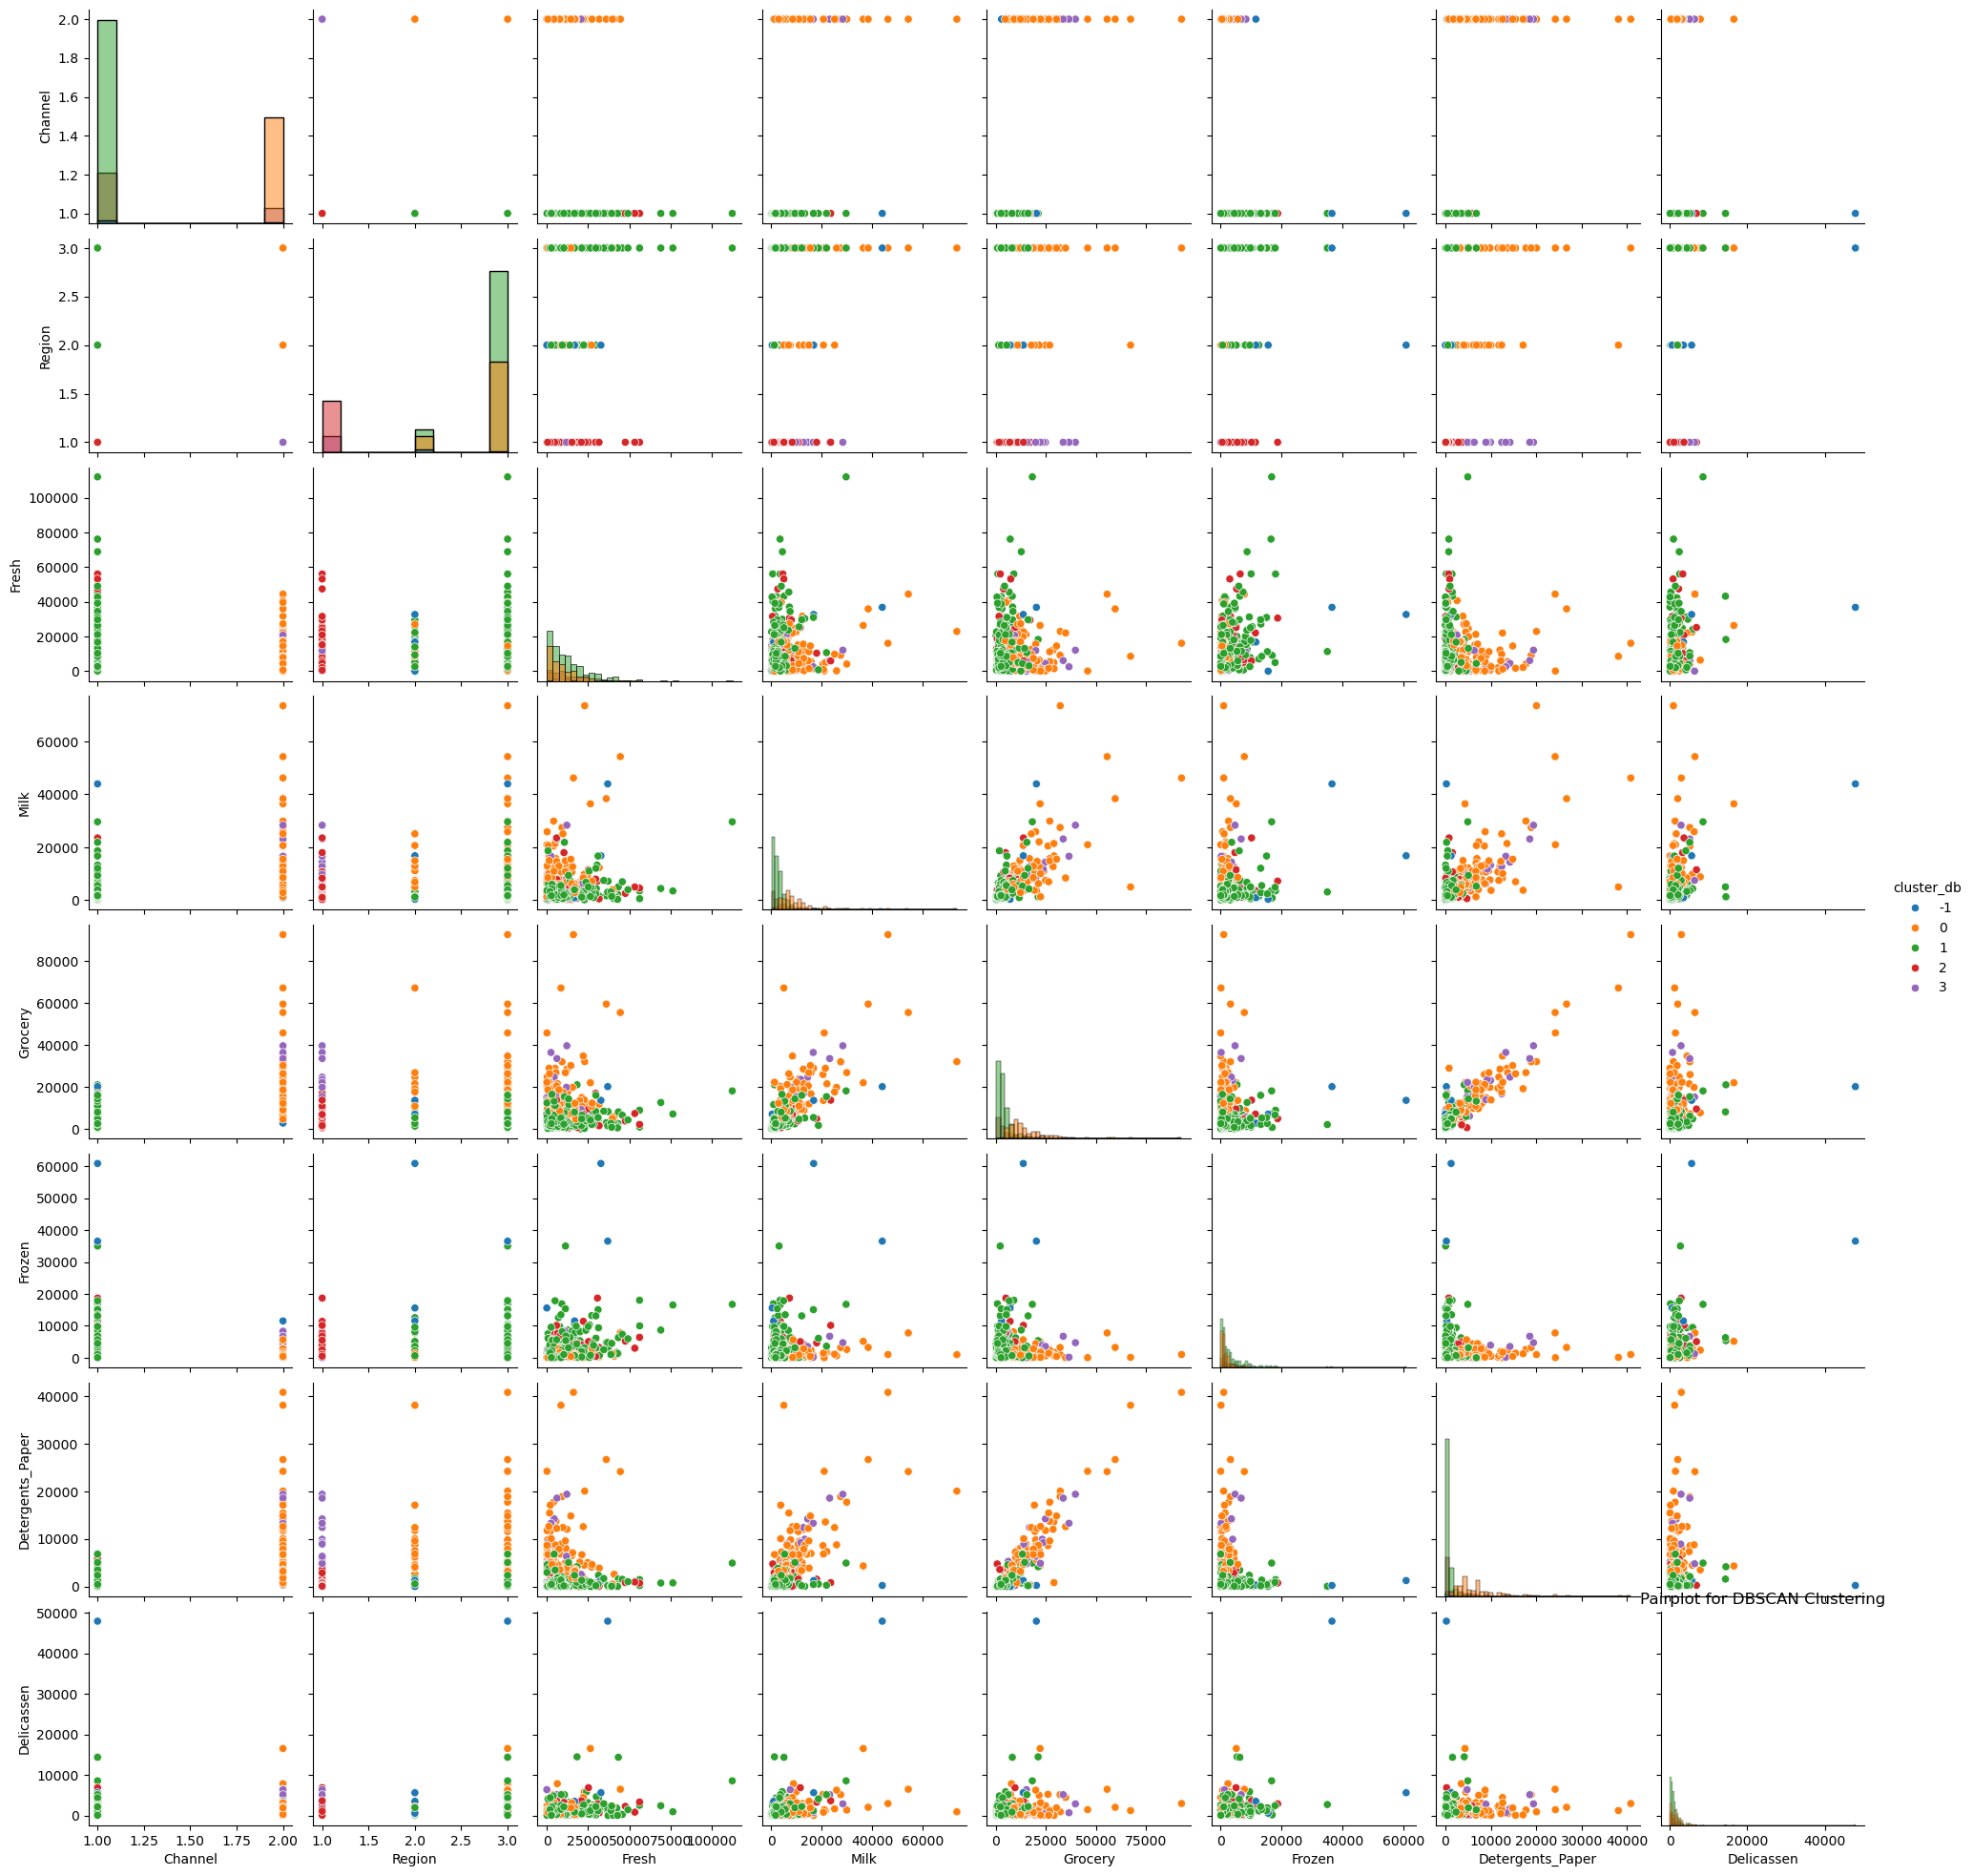

In [71]:
# Add the DBSCAN cluster assignments to the dataset
X0['cluster_db'] = y_db


# Pairplot to visualize clusters created by DBSCAN
print("Pairplot for DBSCAN Clustering with Best Parameters:")
sns.pairplot(data=X0.drop(['cluster_km', 'cluster_ac'], axis=1), hue='cluster_db', diag_kind='hist', palette='tab10')
plt.title("Pairplot for DBSCAN Clustering")
plt.show()

Show the cluster sizes

Pie Chart for DBSCAN Cluster Distribution (Excluding Noise):


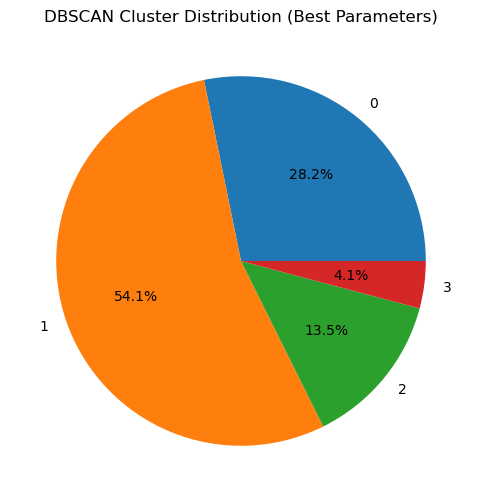

In [72]:
# Calculate cluster sizes, excluding noise (-1)
clust_sizes_db = np.unique(y_db[y_db != -1], return_counts=True)


# Create a pie chart to visualize cluster distribution
print("Pie Chart for DBSCAN Cluster Distribution (Excluding Noise):")
cluster_distribution_db = pd.DataFrame({
   'Cluster': clust_sizes_db[0],
   'Size': clust_sizes_db[1]
})


cluster_distribution_db.set_index('Cluster').plot.pie(
   y='Size',
   autopct='%1.1f%%',
   legend=False,
   figsize=(6, 6),
   title="DBSCAN Cluster Distribution (Best Parameters)"
)
plt.ylabel('')  # Remove the default ylabel for better appearance
plt.show()

## Silhouette plots

Use the function `plot_silhouette` contained in the module `plot_silhouette_w_mean` (provided with the notebook) and from `sklearn.metrics` import the function `silhouette_samples` providing the silhouette score for each sample

`from plot_silhouette_w_mean import plot_silhouette  # python script provided separately`

Hint: use `help(plot_silhouette)` for the meaning of the parameters

Hint: for DBSCAN you should exclude the rows of noise

Silhouette Analysis for KMeans:


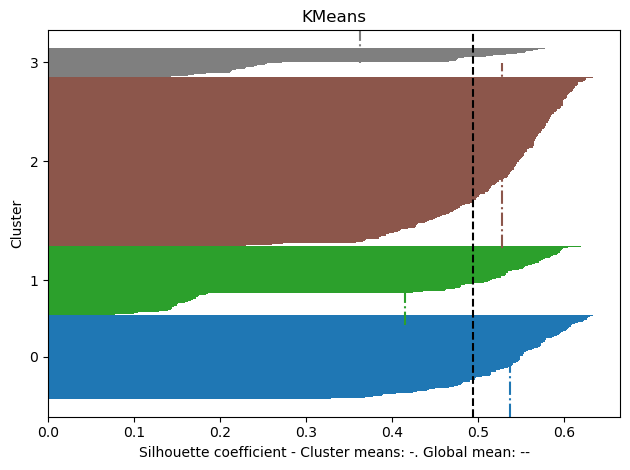

Silhouette Analysis for Agglomerative Clustering:


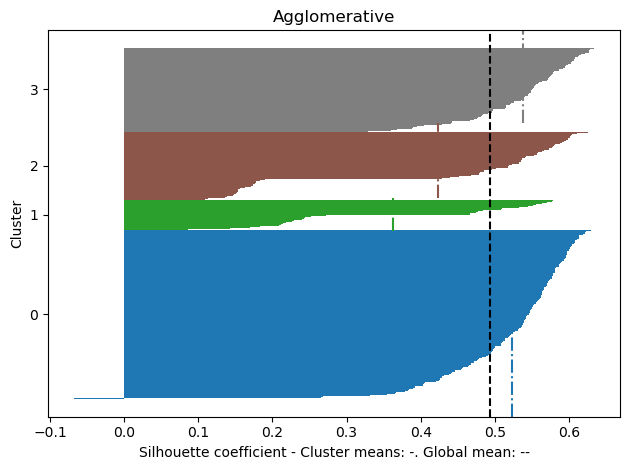

Silhouette Analysis for DBSCAN:


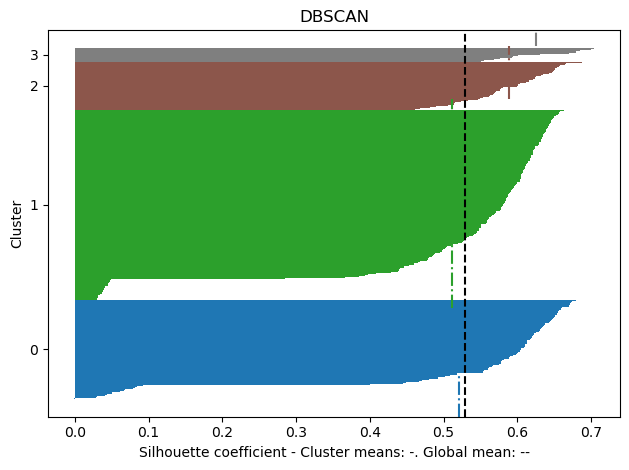

In [74]:
from plot_silhouette_w_mean import plot_silhouette  # python script provided separately
# Silhouette plot for KMeans
print("Silhouette Analysis for KMeans:")
plt.title('KMeans')
silhouette_km = silhouette_samples(X, y_km)  # Compute silhouette scores for KMeans
plot_silhouette(silhouette_km, y_km)  # Plot silhouette scores
plt.show()


# Silhouette plot for Agglomerative Clustering
print("Silhouette Analysis for Agglomerative Clustering:")
plt.title('Agglomerative')
silhouette_ac = silhouette_samples(X, y_ac)  # Compute silhouette scores for Agglomerative Clustering
plot_silhouette(silhouette_ac, y_ac)  # Plot silhouette scores
plt.show()


# Silhouette plot for DBSCAN
print("Silhouette Analysis for DBSCAN:")
plt.title('DBSCAN')
silhouette_db = silhouette_samples(X.loc[y_db != -1, :], y_db[y_db != -1])  # Compute silhouette scores, excluding noise
plot_silhouette(silhouette_db, y_db[y_db != -1])  # Plot silhouette scores
plt.show()

## Optional - Comparison with __boxplots__

For each of the clustering schemes show how the attribute values are distributed in the clusters

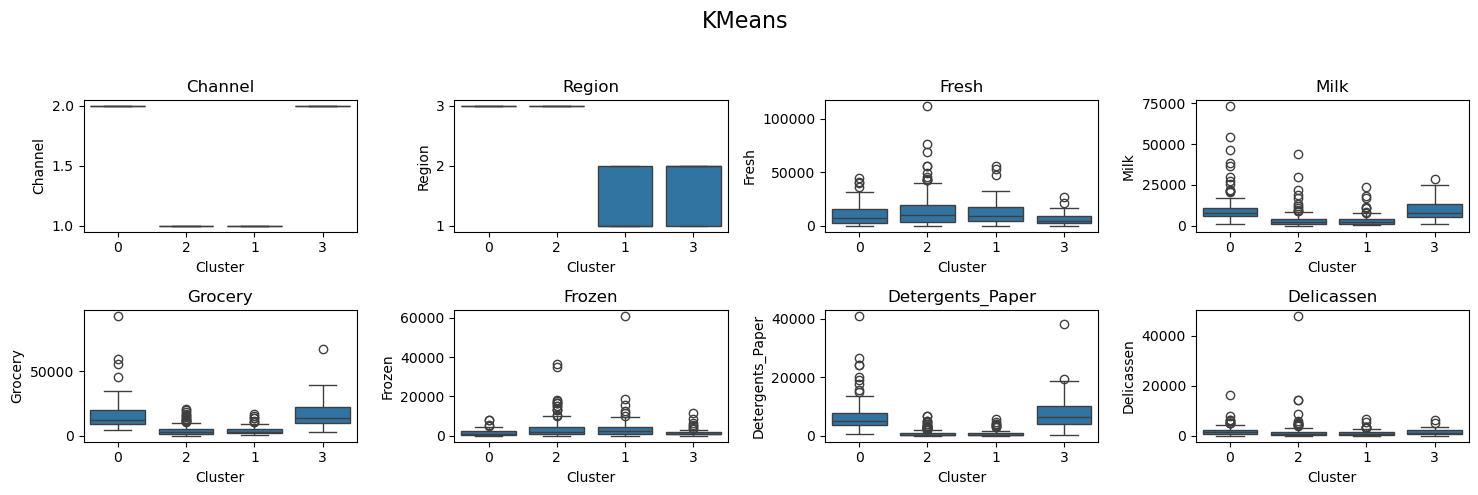

In [75]:
# Boxplots for KMeans Clustering
plt.figure(figsize=(15, 5))
plt.suptitle('KMeans\n', fontsize=16)
pos = 1
for i in X0.columns[0:8]:  # Loop through the first 8 columns (features)
   plt.subplot(2, 4, pos)  # Create a grid of 2 rows and 4 columns
   plt.title(i)  # Set the title to the current feature name
   plt.tight_layout()  # Prevent overlapping of plots
   sns.boxplot(x=X0['cluster_km'].astype('str'), y=X0[i])  # Boxplot for each feature vs. cluster
   plt.xlabel('Cluster')  # Label x-axis as 'Cluster'
   pos += 1
plt.show()


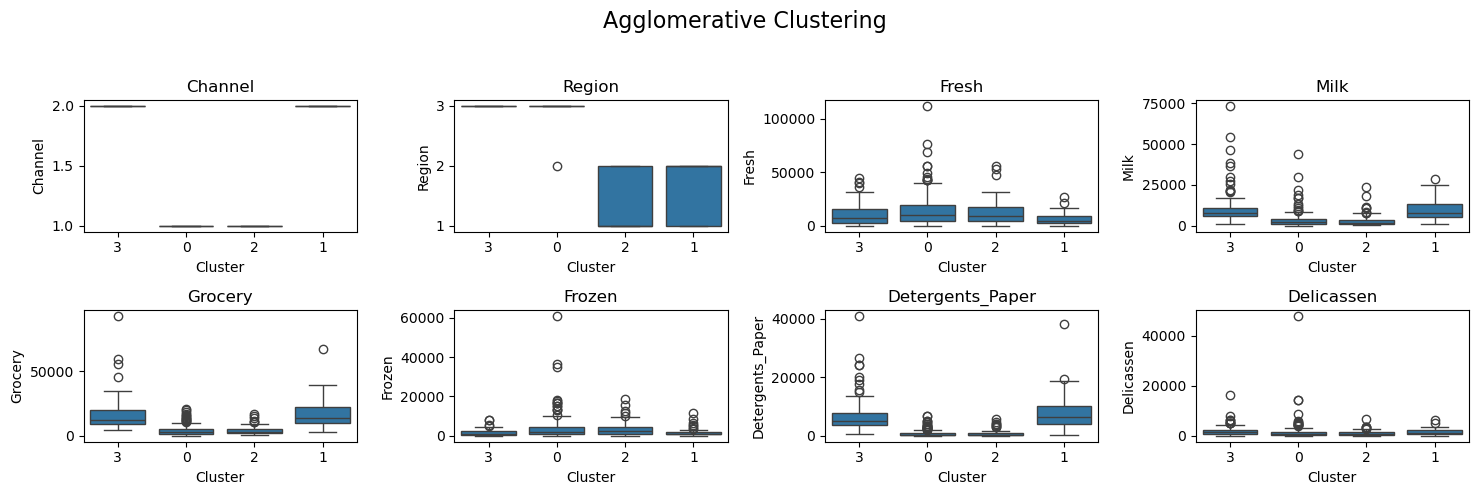

In [76]:
# Boxplots for Agglomerative Clustering
plt.figure(figsize=(15, 5))
plt.suptitle('Agglomerative Clustering\n', fontsize=16)
pos = 1
for i in X0.columns[0:8]:  # Loop through the first 8 columns (features)
   plt.subplot(2, 4, pos)
   plt.title(i)
   plt.tight_layout()
   sns.boxplot(x=X0['cluster_ac'].astype('str'), y=X0[i])  # Boxplot for each feature vs. cluster
   plt.xlabel('Cluster')
   pos += 1
plt.show()


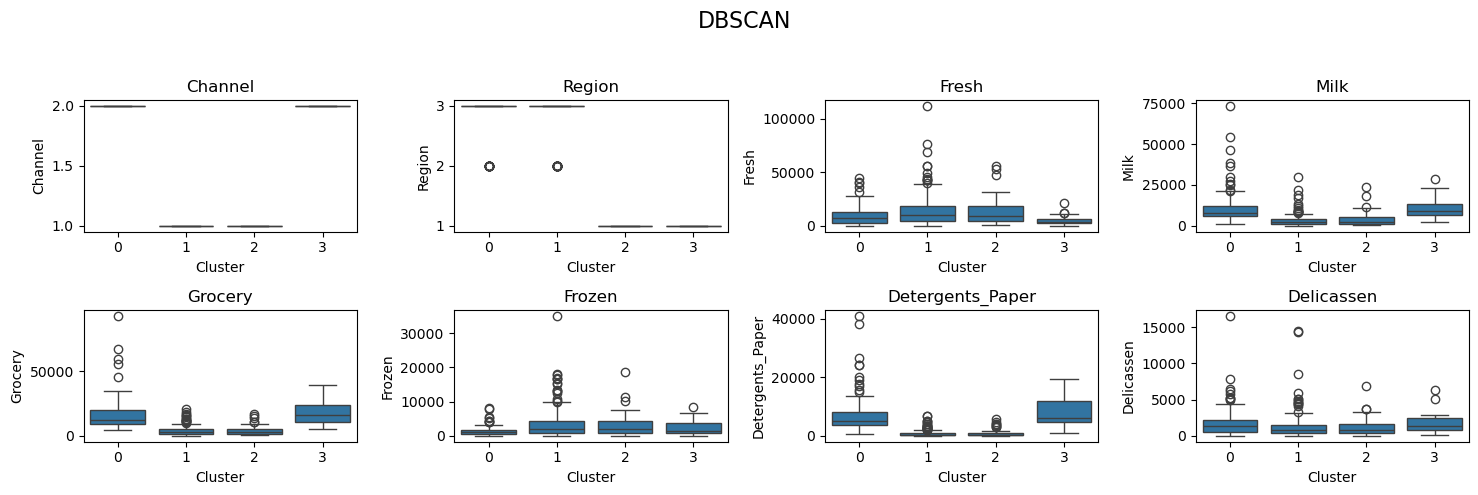

In [77]:
# Boxplots for DBSCAN Clustering (Excluding Noise Points)
X0_c = X0.loc[X0['cluster_db'] != -1].copy()  # Filter out noise points (-1)
plt.figure(figsize=(15, 5))
plt.suptitle('DBSCAN\n', fontsize=16)
pos = 1
for i in X0_c.columns[0:8]:  # Loop through the first 8 columns (features)
   plt.subplot(2, 4, pos)
   plt.title(i)
   plt.tight_layout()
   sns.boxplot(x=X0_c['cluster_db'].astype('str'), y=X0_c[i])  # Boxplot for each feature vs. cluster
   plt.xlabel('Cluster')
   pos += 1
plt.show()


## Control questions
1. Repeat the experiments without the data transformations and comment the result
1. Repeat the final fittings with the numbers of clusters immediately before and after the chosen values and comment the results